# ___Data wrangling & visualization___
------------------

In [2]:
!python --version

Python 3.14.3


The system cannot find the path specified.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
# load in the data for soil and climatic properties and root trait data
root_traits = pd.read_csv(r"../data/chapter3/vin_themeda_root_traits.csv", usecols=("Accession", "SRL", "RTD", "Diameter")) # units => m/g, g/cm3, mm
root_traits.loc[:, "Accession"] = root_traits.Accession.replace(
    {_: _.replace(' ', '_').strip() for _ in root_traits.Accession.unique()}
).replace({"Mt_Fox_N_Park_QLD": "Mt_Fox_National_Park_QLD", "Sydney": "Sydney_NSW"}) # replace these two to match with the climate info dataset

root_traits.head()

,Accession,SRL,RTD,Diameter
0,Dalby_QLD,16.292527,0.256367,0.5521
1,Dalby_QLD,35.587354,0.145137,0.4965
2,Dalby_QLD,26.271140,0.332818,0.3816
3,Dalby_QLD,17.405689,0.176030,0.6447
4,Mt_Fox_National_Park_QLD,35.094561,0.265127,0.3699


In [4]:
# let's use all the records instead of using group means
# root_traits = root_traits.groupby("Accession", as_index=False).mean()
root_traits

,Accession,SRL,RTD,Diameter
0,Dalby_QLD,16.292527,0.256367,0.552100
1,Dalby_QLD,35.587354,0.145137,0.496500
2,Dalby_QLD,26.271140,0.332818,0.381600
3,Dalby_QLD,17.405689,0.176030,0.644700
4,Mt_Fox_National_Park_QLD,35.094561,0.265127,0.369900
5,Mt_Fox_National_Park_QLD,23.679432,0.214891,0.500300
6,Mt_Fox_National_Park_QLD,34.522452,0.297887,0.351900
7,Mt_Fox_National_Park_QLD,17.399410,0.194183,0.613900
8,Panawonica_WA,21.241229,0.596533,0.317000
9,Panawonica_WA,22.604293,0.116710,0.694700


In [5]:
climate = pd.read_csv(r"../data/chapter3/site_metereology.csv", skiprows=range(2), usecols=("site", "state", "annual_rainfall_mm", "mean_annual_temp_celsius"))
climate.loc[:, "site"] = (climate.site + '_' + climate.state).str.replace(' ', '_')

In [6]:
climate

,site,state,annual_rainfall_mm,mean_annual_temp_celsius
0,Rainbow_Valley_NT,NT,189.3,28.9
1,Panawonica_WA,WA,404.4,34.7
2,Forbes_NSW,NSW,520.4,24.5
3,Hobart_TAS,TAS,611.4,17.0
4,Dalby_QLD,QLD,621.4,27.0
5,Virginia_Gardens_SA,SA,468.7,22.6
6,Mt_Fox_National_Park_QLD,QLD,642.8,29.3
7,Sydney_NSW,NSW,1156.9,23.4


In [7]:
data = pd.merge(left=root_traits, left_on="Accession", right=climate, right_on="site").drop(["site", "state"], axis=1) # cool
data
# now append the soil prop data to this

,Accession,SRL,RTD,Diameter,annual_rainfall_mm,mean_annual_temp_celsius
0,Dalby_QLD,16.292527,0.256367,0.552100,621.4,27.0
1,Dalby_QLD,35.587354,0.145137,0.496500,621.4,27.0
2,Dalby_QLD,26.271140,0.332818,0.381600,621.4,27.0
3,Dalby_QLD,17.405689,0.176030,0.644700,621.4,27.0
4,Mt_Fox_National_Park_QLD,35.094561,0.265127,0.369900,642.8,29.3
5,Mt_Fox_National_Park_QLD,23.679432,0.214891,0.500300,642.8,29.3
6,Mt_Fox_National_Park_QLD,34.522452,0.297887,0.351900,642.8,29.3
7,Mt_Fox_National_Park_QLD,17.399410,0.194183,0.613900,642.8,29.3
8,Panawonica_WA,21.241229,0.596533,0.317000,404.4,34.7
9,Panawonica_WA,22.604293,0.116710,0.694700,404.4,34.7


In [8]:
# add ploidy info as another column - got the data from Vin
ploidy_lookup = pd.Series(name="ploidy_n", data={
    "Dalby_QLD": 6,
    "Mt_Fox_National_Park_QLD": 4,
    "Panawonica_WA": 2,
    "Rainbow_Valley_NT": 4,
    "Sydney_NSW": 2,
    "Virginia_Gardens_SA": 4
})

In [9]:
data = pd.merge(left=data, left_on="Accession", right=ploidy_lookup, right_index=True) # append the ploidy level information
data

,Accession,SRL,RTD,Diameter,annual_rainfall_mm,mean_annual_temp_celsius,ploidy_n
0,Dalby_QLD,16.292527,0.256367,0.552100,621.4,27.0,6
1,Dalby_QLD,35.587354,0.145137,0.496500,621.4,27.0,6
2,Dalby_QLD,26.271140,0.332818,0.381600,621.4,27.0,6
3,Dalby_QLD,17.405689,0.176030,0.644700,621.4,27.0,6
4,Mt_Fox_National_Park_QLD,35.094561,0.265127,0.369900,642.8,29.3,4
5,Mt_Fox_National_Park_QLD,23.679432,0.214891,0.500300,642.8,29.3,4
6,Mt_Fox_National_Park_QLD,34.522452,0.297887,0.351900,642.8,29.3,4
7,Mt_Fox_National_Park_QLD,17.399410,0.194183,0.613900,642.8,29.3,4
8,Panawonica_WA,21.241229,0.596533,0.317000,404.4,34.7,2
9,Panawonica_WA,22.604293,0.116710,0.694700,404.4,34.7,2


In [10]:
# soil properties data
soil = pd.read_csv(r"../data/chapter3/CSBP_soil_analysis_Themeda_and_Sorghum.csv")# , usecols=("Customer Sample ID", "Sample Name 2", ""))
soil = soil.rename({_: _.lower().strip().replace(' ', '_').replace('%', "prcnt").replace('(', '').replace(')', '') for _ in soil.columns}, axis=1) # clean up the column names
soil = soil.drop(["lab_number", "date_received", "customer_sample_id", "sample_name_1", "latitude", "longitude", "depth", "colour", "gravel_percent", "texture"], axis=1) # drop useless columns
soil = soil.query("sample_name_2.isin(('Cobbler Ck SA', 'Dalby Qld', 'Mt Fox Qld', 'Pannawonica WA', 'Rainbow Valley NT', 'Hornsby Heights NSW'))").reset_index(drop=True) # filter the six needed rows
soil.loc[:, "sample_name_2"] = soil.sample_name_2.replace({ # update the site names to match the other datsets
    "Cobbler Ck SA": "Virginia_Gardens_SA", "Dalby Qld": "Dalby_QLD", "Hornsby Heights NSW": "Sydney_NSW", "Mt Fox Qld": "Mt_Fox_National_Park_QLD",
    "Pannawonica WA": "Panawonica_WA", "Rainbow Valley NT": "Rainbow_Valley_NT"
})

In [11]:
soil

,sample_name_2,ammonium_nitrogen,nitrate_nitrogen,phosphorus_colwell,potassium_colwell,sulfur,organic_carbon,conductivity,ph_level_cacl2,ph_level_h2o,total_nitrogen,total_phosphorus,total_carbon,prcnt_clay,prcnt_course_sand,prcnt_fine_sand,prcnt_sand,prcnt_silt
0,Virginia_Gardens_SA,2,< 1,5,511,10.7,2.28,0.092,6.1,7.0,0.22,258.6,3.07,31.69,18.82,29.01,47.83,20.48
1,Dalby_QLD,6,< 1,18,398,4,2.88,0.069,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
2,Sydney_NSW,9,< 1,4,206,4.2,3.26,0.052,4.9,5.9,0.18,229.2,4.04,13.88,51.89,23.51,75.4,10.72
3,Mt_Fox_National_Park_QLD,6,< 1,6,314,3.6,1.71,0.035,5.7,6.7,0.19,157.5,2.66,21.6,33.49,22.22,55.71,22.69
4,Panawonica_WA,2,13,8,385,12.8,1.53,0.232,7.2,8.0,0.14,184.2,2.27,25.64,6,29.82,35.82,38.54
5,Rainbow_Valley_NT,1,< 1,6,125,1.1,0.25,0.061,7.5,8.8,0.02,89.7,0.51,5.8,60.38,31.88,92.26,1.95


In [14]:
soil.dtypes # WTF???

sample_name_2             str
ammonium_nitrogen         str
nitrate_nitrogen          str
phosphorus_colwell        str
potassium_colwell         str
sulfur                    str
organic_carbon            str
conductivity              str
ph_level_cacl2        float64
ph_level_h2o          float64
total_nitrogen            str
total_phosphorus          str
total_carbon              str
prcnt_clay                str
prcnt_course_sand         str
prcnt_fine_sand           str
prcnt_sand                str
prcnt_silt                str
dtype: object

In [12]:
def _string_to_float(value: str) -> float:
    """
    if the value is <1 let'set that to 0!! => this is an arbitrary decision
    """
    try:
        return float(value.strip())
    except ValueError:
        return 0.00000

In [15]:
soil.nitrate_nitrogen.apply(_string_to_float)

0     0.0
1     0.0
2     0.0
3     0.0
4    13.0
5     0.0
Name: nitrate_nitrogen, dtype: float64

In [21]:
soil.astype({col: float for col in soil.columns[1:]})

ValueError: could not convert string to float: '< 1': Error while type casting for column 'nitrate_nitrogen'

In [14]:
soil = soil.drop(["prcnt_course_sand", "prcnt_fine_sand"], axis=1)
soil

,sample_name_2,ammonium_nitrogen,nitrate_nitrogen,phosphorus_colwell,potassium_colwell,sulfur,organic_carbon,conductivity,ph_level_cacl2,ph_level_h2o,total_nitrogen,total_phosphorus,total_carbon,prcnt_clay,prcnt_sand,prcnt_silt
0,Virginia_Gardens_SA,2,0.0,5,511,10.7,2.28,0.092,6.1,7.0,0.22,258.6,3.07,31.69,47.83,20.48
1,Dalby_QLD,6,0.0,18,398,4,2.88,0.069,6.0,6.9,0.27,402.1,3.96,23.11,62.15,14.74
2,Sydney_NSW,9,0.0,4,206,4.2,3.26,0.052,4.9,5.9,0.18,229.2,4.04,13.88,75.4,10.72
3,Mt_Fox_National_Park_QLD,6,0.0,6,314,3.6,1.71,0.035,5.7,6.7,0.19,157.5,2.66,21.6,55.71,22.69
4,Panawonica_WA,2,13.0,8,385,12.8,1.53,0.232,7.2,8.0,0.14,184.2,2.27,25.64,35.82,38.54
5,Rainbow_Valley_NT,1,0.0,6,125,1.1,0.25,0.061,7.5,8.8,0.02,89.7,0.51,5.8,92.26,1.95


In [15]:
# pH(H2O) vs pH(CaCl2)
# https://agriculture.vic.gov.au/farm-management/soil/understanding-soil-tests-for-pastures
# Soil pH CaCl2 values are usually between 0.5 to 1.1 units lower than pH (water). The pH (water) value readily reflects current soil conditions, but is subject to seasonal variations.
# The CaCl2 test is useful for long term monitoring of pH and is less subject to seasonal variations

In [16]:
# # https://soilqualityknowledgebase.org.au/resources/soil-phosphorus-testing-colwell-p-and-dgt-p/

# Soil contains phosphorus that can be conceptualised as four pools: solution phosphorus, sorbed phosphorus, mineral phosphorus and organic phosphorus.
# The amount of phosphorus measured by a soil test is dependent on the amount of phosphorus present in each pool and the ability of the soil test method to extract phosphorus from each pool. 
# For the test to be a useful predictor of crop yield responses to fertiliser phosphorus, the test must measure phosphorus that is available to crops for the soil-crop system in question.

# Colewell method for soil P
# In a Colwell phosphorus test, an extract is obtained by adding a soil sample to a sodium bicarbonate solution adjusted to pH 8.5, and agitating for 16 hours. This extract is then acidified before its phosphorus 
# concentration is measured colorimetrically. The Colwell method measures sorbed and solution phosphorus, but does not provide any information on the equilibrium between these two pools, which is determined by the
# phosphors buffering capacity of the soil. The phosphorus buffering index (PBI) is used in combination with Colwell-P to assess the levels of soil P supply to crops and pastures. As the phosphorus buffering index 
# increases, the level of Colwell-P required to provide a sufficient level of phosphorus for crops and pastures increases.

<a src="https://soilqualityknowledgebase.org.au/wp-content/uploads/2023/11/soil-phosphorus-pools-diagram-simple_PNG.png">Image source</a><br><br>

<img src="./soil-phosphorus-pools-diagram-simple_PNG.png" width="400px">

In [14]:
# meta info - climate and soil properties
data = pd.merge(left=data, left_on="Accession", right=soil, right_on="sample_name_2").drop(["sample_name_2", "RTD"], axis=1)
data

,Accession,SRL,Diameter,annual_rainfall_mm,mean_annual_temp_celsius,ploidy_n,ammonium_nitrogen,nitrate_nitrogen,phosphorus_colwell,potassium_colwell,...,ph_level_cacl2,ph_level_h2o,total_nitrogen,total_phosphorus,total_carbon,prcnt_clay,prcnt_course_sand,prcnt_fine_sand,prcnt_sand,prcnt_silt
0,Dalby_QLD,16.292527,0.552100,621.4,27.0,6,6,0.0,18,398,...,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
1,Dalby_QLD,35.587354,0.496500,621.4,27.0,6,6,0.0,18,398,...,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
2,Dalby_QLD,26.271140,0.381600,621.4,27.0,6,6,0.0,18,398,...,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
3,Dalby_QLD,17.405689,0.644700,621.4,27.0,6,6,0.0,18,398,...,6.0,6.9,0.27,402.1,3.96,23.11,35.26,26.89,62.15,14.74
4,Mt_Fox_National_Park_QLD,35.094561,0.369900,642.8,29.3,4,6,0.0,6,314,...,5.7,6.7,0.19,157.5,2.66,21.6,33.49,22.22,55.71,22.69
5,Mt_Fox_National_Park_QLD,23.679432,0.500300,642.8,29.3,4,6,0.0,6,314,...,5.7,6.7,0.19,157.5,2.66,21.6,33.49,22.22,55.71,22.69
6,Mt_Fox_National_Park_QLD,34.522452,0.351900,642.8,29.3,4,6,0.0,6,314,...,5.7,6.7,0.19,157.5,2.66,21.6,33.49,22.22,55.71,22.69
7,Mt_Fox_National_Park_QLD,17.399410,0.613900,642.8,29.3,4,6,0.0,6,314,...,5.7,6.7,0.19,157.5,2.66,21.6,33.49,22.22,55.71,22.69
8,Panawonica_WA,21.241229,0.317000,404.4,34.7,2,2,13.0,8,385,...,7.2,8.0,0.14,184.2,2.27,25.64,6,29.82,35.82,38.54
9,Panawonica_WA,22.604293,0.694700,404.4,34.7,2,2,13.0,8,385,...,7.2,8.0,0.14,184.2,2.27,25.64,6,29.82,35.82,38.54


In [15]:
data.dtypes # why do we have so many object types????

Accession                    object
SRL                         float64
Diameter                    float64
annual_rainfall_mm          float64
mean_annual_temp_celsius    float64
ploidy_n                      int64
ammonium_nitrogen            object
nitrate_nitrogen             object
phosphorus_colwell           object
potassium_colwell            object
sulfur                       object
organic_carbon               object
conductivity                 object
ph_level_cacl2              float64
ph_level_h2o                float64
total_nitrogen               object
total_phosphorus             object
total_carbon                 object
prcnt_clay                   object
prcnt_course_sand            object
prcnt_fine_sand              object
prcnt_sand                   object
prcnt_silt                   object
dtype: object

In [28]:
data.convert_dtypes(convert_floating=True, convert_string=False).dtypes # we still have so many string (object) types

Accession                   string[python]
SRL                                Float64
Diameter                           Float64
annual_rainfall_mm                 Float64
mean_annual_temp_celsius           Float64
ploidy_n                             Int64
ammonium_nitrogen           string[python]
nitrate_nitrogen                     Int64
phosphorus_colwell          string[python]
potassium_colwell           string[python]
sulfur                      string[python]
organic_carbon              string[python]
conductivity                string[python]
ph_level_cacl2                     Float64
ph_level_h2o                       Float64
total_nitrogen              string[python]
total_phosphorus            string[python]
total_carbon                string[python]
prcnt_clay                  string[python]
prcnt_sand                  string[python]
prcnt_silt                  string[python]
dtype: object

In [16]:
data = data.astype({_: np.float64 for _ in data.columns[1:]}) # YES!

In [17]:
data.dtypes

Accession                    object
SRL                         float64
Diameter                    float64
annual_rainfall_mm          float64
mean_annual_temp_celsius    float64
ploidy_n                    float64
ammonium_nitrogen           float64
nitrate_nitrogen            float64
phosphorus_colwell          float64
potassium_colwell           float64
sulfur                      float64
organic_carbon              float64
conductivity                float64
ph_level_cacl2              float64
ph_level_h2o                float64
total_nitrogen              float64
total_phosphorus            float64
total_carbon                float64
prcnt_clay                  float64
prcnt_course_sand           float64
prcnt_fine_sand             float64
prcnt_sand                  float64
prcnt_silt                  float64
dtype: object

In [46]:
data

,Accession,SRL,Diameter,annual_rainfall_mm,mean_annual_temp_celsius,ploidy_n,ammonium_nitrogen,nitrate_nitrogen,phosphorus_colwell,potassium_colwell,...,organic_carbon,conductivity,ph_level_cacl2,ph_level_h2o,total_nitrogen,total_phosphorus,total_carbon,prcnt_clay,prcnt_sand,prcnt_silt
0,Dalby_QLD,23.889177,0.518725,621.4,27.0,6.0,6.0,0.0,18.0,398.0,...,2.88,0.069,6.0,6.9,0.27,402.1,3.96,23.11,62.15,14.74
1,Mt_Fox_National_Park_QLD,27.673964,0.459000,642.8,29.3,4.0,6.0,0.0,6.0,314.0,...,1.71,0.035,5.7,6.7,0.19,157.5,2.66,21.60,55.71,22.69
2,Panawonica_WA,18.010786,0.621800,404.4,34.7,2.0,2.0,13.0,8.0,385.0,...,1.53,0.232,7.2,8.0,0.14,184.2,2.27,25.64,35.82,38.54
3,Rainbow_Valley_NT,28.718094,0.501140,189.3,28.9,4.0,1.0,0.0,6.0,125.0,...,0.25,0.061,7.5,8.8,0.02,89.7,0.51,5.80,92.26,1.95
4,Sydney_NSW,37.411013,0.476333,1156.9,23.4,2.0,9.0,0.0,4.0,206.0,...,3.26,0.052,4.9,5.9,0.18,229.2,4.04,13.88,75.40,10.72
5,Virginia_Gardens_SA,31.022919,0.573444,468.7,22.6,4.0,2.0,0.0,5.0,511.0,...,2.28,0.092,6.1,7.0,0.22,258.6,3.07,31.69,47.83,20.48


In [18]:
# serialize the cleaned dataset
data.to_csv(r"./themeda_power.csv", index=False)

In [21]:
# maybe we shouldn't treat ploidy level as a continuous variable???

In [22]:
# what were the units of the soil properties??
pd.read_csv(r"../data/chapter3/CSBP_soil_analysis_Themeda_and_Sorghum.csv").loc[0, :].dropna()

Gravel_percent            %
Ammonium Nitrogen     mg/kg
Nitrate Nitrogen      mg/kg
Phosphorus Colwell    mg/kg
Potassium Colwell     mg/kg
Sulfur                mg/kg
Organic Carbon            %
Conductivity           dS/m
Total Nitrogen            %
Total Phosphorus      mg/kg
Total Carbon              %
% Clay                    %
% Course Sand             %
% Fine Sand               %
% Sand                    %
% Silt                    %
Name: 0, dtype: object

In [23]:
data # response variables are columns 1 and 2

,Accession,SRL,Diameter,annual_rainfall_mm,mean_annual_temp_celsius,ploidy_n,ammonium_nitrogen,nitrate_nitrogen,phosphorus_colwell,potassium_colwell,...,organic_carbon,conductivity,ph_level_cacl2,ph_level_h2o,total_nitrogen,total_phosphorus,total_carbon,prcnt_clay,prcnt_sand,prcnt_silt
0,Dalby_QLD,23.889177,0.518725,621.4,27.0,6,6,0,18,398,...,2.88,0.069,6.0,6.9,0.27,402.1,3.96,23.11,62.15,14.74
1,Mt_Fox_National_Park_QLD,27.673964,0.459,642.8,29.3,4,6,0,6,314,...,1.71,0.035,5.7,6.7,0.19,157.5,2.66,21.6,55.71,22.69
2,Panawonica_WA,18.010786,0.6218,404.4,34.7,2,2,13,8,385,...,1.53,0.232,7.2,8.0,0.14,184.2,2.27,25.64,35.82,38.54
3,Rainbow_Valley_NT,28.718094,0.50114,189.3,28.9,4,1,0,6,125,...,0.25,0.061,7.5,8.8,0.02,89.7,0.51,5.8,92.26,1.95
4,Sydney_NSW,37.411013,0.476333,1156.9,23.4,2,9,0,4,206,...,3.26,0.052,4.9,5.9,0.18,229.2,4.04,13.88,75.4,10.72
5,Virginia_Gardens_SA,31.022919,0.573444,468.7,22.6,4,2,0,5,511,...,2.28,0.092,6.1,7.0,0.22,258.6,3.07,31.69,47.83,20.48


In [34]:
x = data.iloc[:, 3:] # all the other traits
y = data.iloc[:, 1:3] # SRL & RD

In [35]:
model = LinearRegression(n_jobs=16)
scaler = StandardScaler()

In [36]:
scaled_x = scaler.fit_transform(x) # all the predictor variables

In [37]:
scaled_x

array([[ 0.13677438, -0.16085381,  1.69774938,  0.58123819, -0.4472136 ,
         2.16073086,  0.58617936, -0.49329235,  0.90978668, -0.32204783,
        -0.26438635, -0.33794136,  1.28388148,  1.86771107,  1.01599924,
         0.33773479,  0.03388395, -0.30404056],
       [ 0.20848459,  0.4083212 ,  0.24253563,  0.58123819, -0.4472136 ,
        -0.38963999, -0.07180371, -0.58876829, -0.27954339, -0.83935299,
        -0.60431166, -0.55137802,  0.2567763 , -0.6440206 , -0.0770758 ,
         0.15710449, -0.31712831,  0.39725221],
       [-0.59038056,  1.74464514, -1.21267813, -0.81373347,  2.23606798,
         0.03542182,  0.48434865,  1.6071783 , -0.46251725,  2.15797401,
         1.09531488,  0.83596022, -0.38516444, -0.36984547, -0.40499832,
         0.64038025, -1.40123295,  1.79542711],
       [-1.31116871,  0.30933425,  0.24253563, -1.16247639, -0.4472136 ,
        -0.38963999, -1.55226562, -1.18549291, -1.76366469, -0.44376669,
         1.43524019,  1.68970682, -1.92582222, -1.340

In [38]:
# Specific Root Length
model.fit(X=scaled_x, y=y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",16
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
model.coef_ # the first array is for SRL and the second is for RD

array([[ 5.38093774e-01, -2.14198512e+00, -8.63896914e-01,
        -2.32917800e-01, -9.42018317e-01, -1.63318579e+00,
        -5.24441258e-02,  3.62182206e-01,  5.19186720e-01,
        -4.76164523e-01, -5.70683807e-01, -4.41616237e-01,
        -3.55149535e-01, -2.01448333e-01,  1.86927058e-01,
        -1.56651670e-01,  7.73797923e-01, -1.13668824e+00],
       [-3.37811655e-03, -1.01666351e-02, -7.82299725e-03,
        -1.24786265e-02,  9.44144152e-03,  2.31776967e-03,
         6.19608760e-03,  1.67700114e-02,  6.57415044e-03,
         1.76132766e-02,  9.67773919e-03,  8.18683174e-03,
        -2.98585360e-03,  1.12207488e-02,  2.73196956e-03,
         2.45718672e-03,  1.14888131e-03, -3.66983560e-03]])

In [43]:
model.intercept_ # SRL and RD

array([27.78765886,  0.52507368])

In [41]:
pd.DataFrame(index=data.columns[3:], data=model.coef_.T, columns=["SRL", "RD"])

,SRL,RD
annual_rainfall_mm,0.538094,-0.003378
mean_annual_temp_celsius,-2.141985,-0.010167
ploidy_n,-0.863897,-0.007823
ammonium_nitrogen,-0.232918,-0.012479
nitrate_nitrogen,-0.942018,0.009441
phosphorus_colwell,-1.633186,0.002318
potassium_colwell,-0.052444,0.006196
sulfur,0.362182,0.016770
organic_carbon,0.519187,0.006574
conductivity,-0.476165,0.017613


In [7]:
# post power analysis visuaslizations

power = pd.read_csv(r"./power.csv")
power.head()

,NA,3,4,5,6,7,8,9,10,11,12
0,0.100000,0.185,0.232,0.257,0.290,0.326,0.356,0.394,0.468,0.477,0.497
1,0.127586,0.261,0.321,0.365,0.435,0.495,0.538,0.570,0.621,0.655,0.666
2,0.155172,0.372,0.397,0.482,0.560,0.624,0.656,0.706,0.770,0.799,0.837
3,0.182759,0.435,0.553,0.606,0.678,0.772,0.786,0.832,0.891,0.884,0.911
4,0.210345,0.541,0.626,0.709,0.786,0.844,0.883,0.889,0.944,0.950,0.963


In [32]:
power.columns[1:]

Index(['3', '4', '5', '6', '7', '8', '9', '10', '11', '12'], dtype='str')

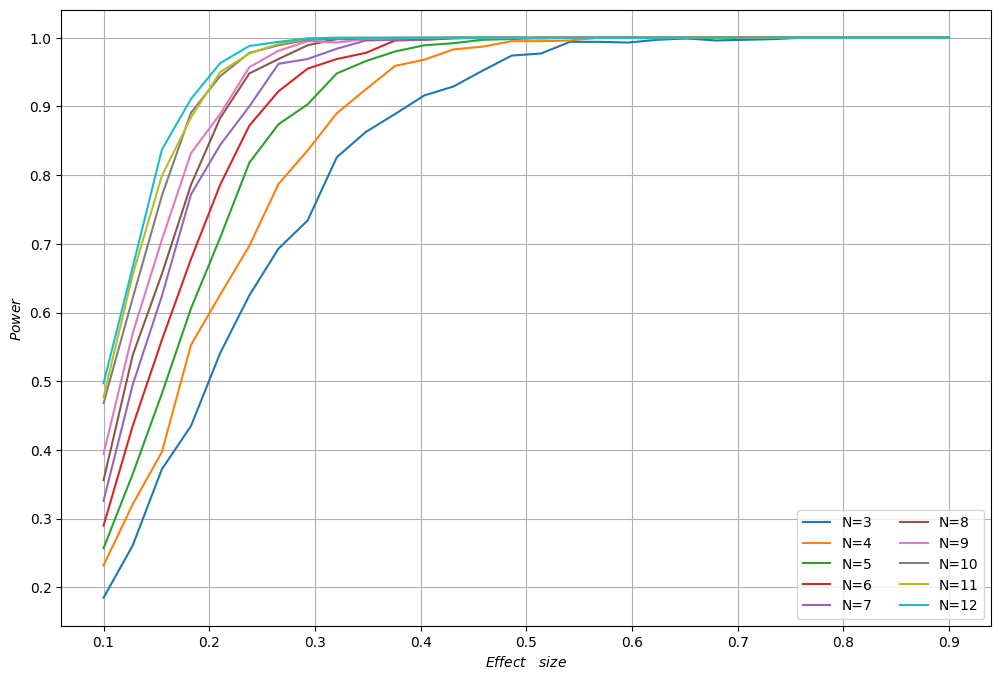

In [39]:
fig, axes = plt.subplots()
fig.set_size_inches(12, 8)
for (col) in power.columns[1:]:
    # print(row.values)
    axes.plot(power.loc[:, "NA"] , power.loc[:, col], label=f"N={col}")
axes.set_xlabel(r"$Effect\hspace{1}size$")
axes.set_ylabel(r"$Power$")
axes.grid()
axes.set_axisbelow(True)
axes.legend(ncols=2)
plt.show()